In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os
import datetime
from concurrent.futures import ThreadPoolExecutor
from itertools import repeat
from tqdm.auto import tqdm
import tensorflow as tf
import tensorflow.keras as keras
from keras.models import Sequential
from keras.layers import Dense, LSTM, GRU, RNN, Dropout, Flatten
from keras.models import Sequential, load_model
from keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# define the plot size default
from pylab import rcParams
rcParams['figure.figsize'] = (12,5)

# load specific forecasting tools
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tools.eval_measures import mse,rmse
plt.rc('font', family='NanumBarunGothic')

In [3]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    tf.random.set_seed(seed)

In [4]:
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

random.seed(SEED)

tf.random.set_seed(SEED)
np.random.seed(SEED)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 새 섹션

In [ ]:
# https://www.machinelearningplus.com/time-series/vector-autoregression-examples-python/
# https://songseungwon.tistory.com/133
# https://www.kaggle.com/code/prakharprasad/time-series-vector-autoregression

In [ ]:
# 심리지수 없는.ver
df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/한이음/시계열_최종(심리지수제외).xlsx')
df = df.drop(df.columns[0], axis=1)
df.head()

,시점,매매가격지수,금리,국내총생산,대출금리,아파트거래량
0,2019-01-01,75.859101,1.75,"455,551.1",3.12,91868
1,2019-02-01,75.772352,1.75,"455,551.1",3.08,78825
2,2019-03-01,75.626463,1.75,"455,551.1",3.04,90720
3,2019-04-01,75.443869,1.75,"480,832.1",2.98,89977
4,2019-05-01,75.339340,1.75,"480,832.1",2.93,82498


In [ ]:
df['매매가격지수'] = pd.to_numeric(df['매매가격지수'], errors='coerce')
df['국내총생산'] = df['국내총생산'].str.replace(',', '').astype(float)
df['대출금리'] = pd.to_numeric(df['대출금리'], errors='coerce')
df['아파트거래량'] = pd.to_numeric(df['아파트거래량'], errors='coerce')
df.dtypes

시점        datetime64[ns]
매매가격지수           float64
금리               float64
국내총생산            float64
대출금리             float64
아파트거래량             int64
dtype: object

In [ ]:
df.set_index('시점', inplace=True)
df.head()

,매매가격지수,금리,국내총생산,대출금리,아파트거래량
시점,,,,,
2019-01-01,75.859101,1.75,455551.1,3.12,91868
2019-02-01,75.772352,1.75,455551.1,3.08,78825
2019-03-01,75.626463,1.75,455551.1,3.04,90720
2019-04-01,75.443869,1.75,480832.1,2.98,89977
2019-05-01,75.339340,1.75,480832.1,2.93,82498


In [ ]:
df.tail()

,매매가격지수,금리,국내총생산,대출금리,아파트거래량
시점,,,,,
2022-11-01,98.057422,3.00,556628.7,4.74,38186
2022-12-01,96.569873,3.25,556628.7,4.63,52385
2023-01-01,94.724287,3.25,523816.2,4.58,39124
2023-02-01,93.626154,3.50,523816.2,4.56,63909
2023-03-01,92.481888,3.50,523816.2,4.40,59750


IndexError: ignored

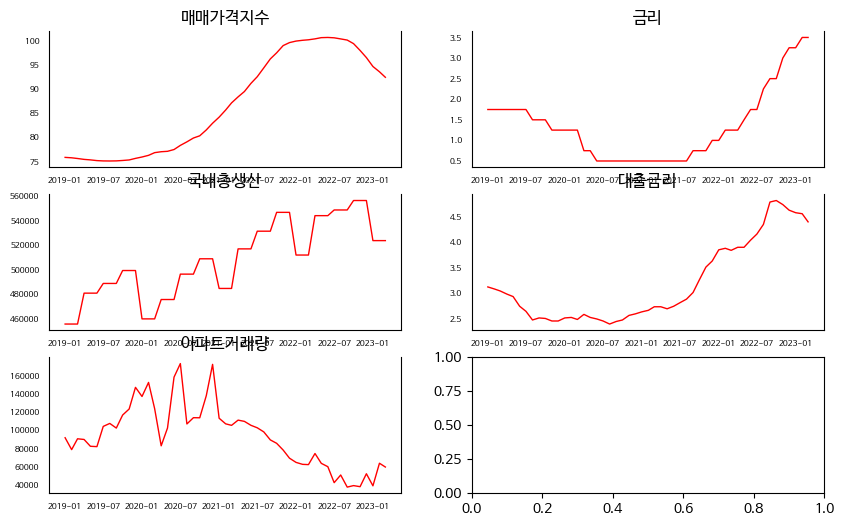

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=2, dpi=100, figsize=(10,6))
for i, ax in enumerate(axes.flatten()):
    data = df[df.columns[i]]
    ax.plot(data, color='red', linewidth=1)
    # Decorations
    ax.set_title(df.columns[i])
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')
    ax.spines["top"].set_alpha(0)
    ax.tick_params(labelsize=6)

plt.tight_layout();

##### Granger 관계
##### 단일 시계열보다 다중 시계열로 설명력을 더 얻을 수 있는가?에 대한 검정
##### p-value가 0.05 이하이면 귀무가설이 기각되므로 그랜저 인과관계를 따르게 된다.

In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests
maxlag=12
test = 'ssr_chi2test'
def grangers_causation_matrix(data, variables, test='ssr_chi2test', verbose=False):
    df = pd.DataFrame(np.zeros((len(variables), len(variables))), columns=variables, index=variables)
    for c in df.columns:
        for r in df.index:
            test_result = grangercausalitytests(data[[r, c]], maxlag=maxlag, verbose=False)
            p_values = [round(test_result[i+1][0][test][1],4) for i in range(maxlag)]
            if verbose: print(f'Y = {r}, X = {c}, P Values = {p_values}')
            min_p_value = np.min(p_values)
            df.loc[r, c] = min_p_value
    df.columns = [var + '_x' for var in variables]
    df.index = [var + '_y' for var in variables]
    return df

grangers_causation_matrix(df, variables = df.columns)

# p_value 0.05보다 값이 작은 경우
# 1) 국내총생산이 매매가격지수를 선행하며 영향을 끼침
# 2) 아파트 거래량이 금리를 선행하며 영향을 끼침

,매매가격지수_x,금리_x,국내총생산_x,대출금리_x,아파트거래량_x
매매가격지수_y,1.0,0.0,0.0006,0.0,0.0000
금리_y,0.0,1.0,0.0000,0.0,0.0002
국내총생산_y,0.0,0.0,1.0000,0.0,0.0000
대출금리_y,0.0,0.0,0.0000,1.0,0.0759
아파트거래량_y,0.0,0.0,0.0000,0.0,1.0000


##### 요한슨의 공적분 검정
##### 다중 시계열이 장기적 기간을 두고 안정성을 보이는가?에 대한 검정

In [ ]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

def cointegration_test(df, alpha=0.05):
    out = coint_johansen(df,-1,5)
    d = {'0.90':0, '0.95':1, '0.99':2}
    traces = out.lr1
    cvts = out.cvt[:, d[str(1-alpha)]]
    def adjust(val, length= 6): return str(val).ljust(length)

    # Summary
    print('Name   ::  Test Stat > C(95%)    =>   Signif  \n', '--'*20)
    for col, trace, cvt in zip(df.columns, traces, cvts):
        print(adjust(col), ':: ', adjust(round(trace,2), 9), ">", adjust(cvt, 8), ' =>  ' , trace > cvt)

cointegration_test(df)
# 모든 변수들 간에 유의미한 공적분 관계가 있음 -> 변수들 간 장기적인 경향 또는 상관관계가 존재함을 의미

Name   ::  Test Stat > C(95%)    =>   Signif  
 ----------------------------------------
매매가격지수 ::  123.96    > 60.0627   =>   True
금리     ::  69.06     > 40.1749   =>   True
국내총생산  ::  36.24     > 24.2761   =>   True
대출금리   ::  14.42     > 12.3212   =>   True
아파트거래량 ::  4.58      > 4.1296    =>   True


In [ ]:
nobs = 3
df_train, df_test = df[0:-nobs], df[-nobs:]

print(df_train.shape)
print(df_test.shape)

(48, 5)
(3, 5)


##### 정상 시계열인지? -> ADF 검정

In [ ]:
def adfuller_test(series, signif=0.05, name='', verbose=False):
    """Perform ADFuller to test for Stationarity of given series and print report"""
    r = adfuller(series, autolag='AIC')
    output = {'test_statistic':round(r[0], 4), 'pvalue':round(r[1], 4), 'n_lags':round(r[2], 4), 'n_obs':r[3]}
    p_value = output['pvalue']
    def adjust(val, length= 6): return str(val).ljust(length)

    # Print Summary
    print(f'    Augmented Dickey-Fuller Test on "{name}"', "\n   ", '-'*47)
    print(f' Null Hypothesis: Data has unit root. Non-Stationary.')
    print(f' Significance Level    = {signif}')
    print(f' Test Statistic        = {output["test_statistic"]}')
    print(f' No. Lags Chosen       = {output["n_lags"]}')

    for key,val in r[4].items():
        print(f' Critical value {adjust(key)} = {round(val, 3)}')

    if p_value <= signif:
        print(f" => P-Value = {p_value}. Rejecting Null Hypothesis.")
        print(f" => Series is Stationary.")
    else:
        print(f" => P-Value = {p_value}. Weak evidence to reject the Null Hypothesis.")
        print(f" => Series is Non-Stationary.")

In [ ]:
for name, column in df_train.iteritems():
    adfuller_test(column, name=column.name)
    print('\n')

    Augmented Dickey-Fuller Test on "매매가격지수" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -2.5496
 No. Lags Chosen       = 1
 Critical value 1%     = -3.581
 Critical value 5%     = -2.927
 Critical value 10%    = -2.602
 => P-Value = 0.1039. Weak evidence to reject the Null Hypothesis.
 => Series is Non-Stationary.


    Augmented Dickey-Fuller Test on "금리" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -0.3041
 No. Lags Chosen       = 3
 Critical value 1%     = -3.589
 Critical value 5%     = -2.93
 Critical value 10%    = -2.603
 => P-Value = 0.9249. Weak evidence to reject the Null Hypothesis.
 => Series is Non-Stationary.


    Augmented Dickey-Fuller Test on "국내총생산" 
    -----------------------------------------------
 Null Hypothesis: Data has unit ro

In [ ]:
# 1차 차분 -> 국내총생산, 아파트 거래량은 정상 시계열로 됨
df_differenced = df_train.diff().dropna()

In [ ]:
for name, column in df_differenced.iteritems():
    adfuller_test(column, name=column.name)
    print('\n')

    Augmented Dickey-Fuller Test on "매매가격지수" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -0.223
 No. Lags Chosen       = 0
 Critical value 1%     = -3.581
 Critical value 5%     = -2.927
 Critical value 10%    = -2.602
 => P-Value = 0.9357. Weak evidence to reject the Null Hypothesis.
 => Series is Non-Stationary.


    Augmented Dickey-Fuller Test on "금리" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -0.6786
 No. Lags Chosen       = 2
 Critical value 1%     = -3.589
 Critical value 5%     = -2.93
 Critical value 10%    = -2.603
 => P-Value = 0.8522. Weak evidence to reject the Null Hypothesis.
 => Series is Non-Stationary.


    Augmented Dickey-Fuller Test on "국내총생산" 
    -----------------------------------------------
 Null Hypothesis: Data has unit roo

In [ ]:
# 2차 차분 -> 모든 변수 다 정상시계열이 됨 ..?
df_differenced = df_differenced.diff().dropna()

In [ ]:
for name, column in df_differenced.iteritems():
    adfuller_test(column, name=column.name)
    print('\n')

    Augmented Dickey-Fuller Test on "매매가격지수" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -6.8774
 No. Lags Chosen       = 0
 Critical value 1%     = -3.585
 Critical value 5%     = -2.928
 Critical value 10%    = -2.602
 => P-Value = 0.0. Rejecting Null Hypothesis.
 => Series is Stationary.


    Augmented Dickey-Fuller Test on "금리" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -11.2397
 No. Lags Chosen       = 1
 Critical value 1%     = -3.589
 Critical value 5%     = -2.93
 Critical value 10%    = -2.603
 => P-Value = 0.0. Rejecting Null Hypothesis.
 => Series is Stationary.


    Augmented Dickey-Fuller Test on "국내총생산" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05

In [ ]:
def cointegration_test(df_differenced, alpha=0.05):
    out = coint_johansen(df_differenced,-1,5)
    d = {'0.90':0, '0.95':1, '0.99':2}
    traces = out.lr1
    cvts = out.cvt[:, d[str(1-alpha)]]
    def adjust(val, length= 6): return str(val).ljust(length)

    # Summary
    print('Name   ::  Test Stat > C(95%)    =>   Signif  \n', '--'*20)
    for col, trace, cvt in zip(df.columns, traces, cvts):
        print(adjust(col), ':: ', adjust(round(trace,2), 9), ">", adjust(cvt, 8), ' =>  ' , trace > cvt)

cointegration_test(df)
# 모든 변수들 간에 유의미한 공적분 관계가 있음 -> 변수들 간 장기적인 경향 또는 상관관계가 존재함을 의미

Name   ::  Test Stat > C(95%)    =>   Signif  
 ----------------------------------------
매매가격지수 ::  123.96    > 60.0627   =>   True
금리     ::  69.06     > 40.1749   =>   True
국내총생산  ::  36.24     > 24.2761   =>   True
대출금리   ::  14.42     > 12.3212   =>   True
아파트거래량 ::  4.58      > 4.1296    =>   True


## 차수 선택

In [ ]:
model = VAR(df_differenced)
for i in [1,2,3,4,5,6,7,8,9]:
    result = model.fit(i)
    print('Lag Order =', i)
    print('AIC : ', result.aic)
    print('BIC : ', result.bic)
    print('FPE : ', result.fpe)
    print('HQIC: ', result.hqic, '\n')

Lag Order = 1
AIC :  29.88833791117449
BIC :  31.09277957102137
FPE :  9634047078370.65
HQIC:  30.337341668909048 

Lag Order = 2
AIC :  29.775065643641096
BIC :  32.005302686038924
FPE :  9008536668893.564
HQIC:  30.602145055155543 

Lag Order = 3
AIC :  29.689360325272098
BIC :  32.966011703306634
FPE :  9449027879238.842
HQIC:  30.897688087804312 

Lag Order = 4
AIC :  28.998104699499585
BIC :  33.342278745208006
FPE :  6424668453691.798
HQIC:  30.590416302026227 

Lag Order = 5
AIC :  28.768344423023642
BIC :  34.201621707695836
FPE :  9767611701354.957
HQIC:  30.746844447433027 

Lag Order = 6
AIC :  27.143179801470676
BIC :  33.68758768616218
FPE :  8080349964778.308
HQIC:  29.509431043935763 

Lag Order = 7


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


LinAlgError: ignored

In [ ]:
x = model.select_order(maxlags=6)
x.summary()

,AIC,BIC,FPE,HQIC
0,30.72,30.93*,2.200e+13,30.80
1,30.33,31.60,1.502e+13,30.79
2,30.11,32.43,1.277e+13,30.95
3,29.86,33.23,1.173e+13,31.08
4,28.59,33.03,4.688e+12*,30.20
5,28.24,33.73,6.426e+12,30.22
6,27.14*,33.69,8.080e+12,29.51*


In [ ]:
model_fitted = model.fit(6)
model_fitted.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 12, Nov, 2023
Time:                     15:07:43
--------------------------------------------------------------------
No. of Equations:         5.00000    BIC:                    33.6876
Nobs:                     40.0000    HQIC:                   29.5094
Log likelihood:          -671.651    FPE:                8.08035e+12
AIC:                      27.1432    Det(Omega_mle):     4.58605e+11
--------------------------------------------------------------------
Results for equation 매매가격지수
               coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------
const             0.018351         0.065117            0.282           0.778
L1.매매가격지수         0.245383         0.411164            0.597           0.551
L1.금리            -0.391792         0.588873           -0.665           0.50

##### 잔차에 상관성이 있는지? -> 더븐-왓트슨 검정

In [ ]:
# 0~4 사이의 값을 가지며, 2에 가까울수록 상관성이 없는 것이고 0에 가까울수록 양의 상관성, 4에 가까울수록 음의 상관성이 존재

from statsmodels.stats.stattools import durbin_watson
def adjust(val, length=6):
    return str(val).ljust(length)
out = durbin_watson(model_fitted.resid)

for col, val in zip(df.columns, out):
    print(adjust(col), ':', round(val, 2))

매매가격지수 : 2.29
금리     : 2.03
국내총생산  : 1.72
대출금리   : 1.64
아파트거래량 : 2.22


In [ ]:
lag_order = model_fitted.k_ar
print(lag_order)  #> 4

# Input data for forecasting
forecast_input = df_differenced.values[-lag_order:]
forecast_input

6


array([[-1.15174039e-01, -2.50000000e-01,  4.65270000e+03,
        -2.00000000e-02, -1.38740000e+04],
       [-1.53387768e-01,  5.00000000e-01, -4.65270000e+03,
         7.00000000e-02,  2.59360000e+04],
       [-1.28011727e-02, -2.50000000e-01,  0.00000000e+00,
         2.50000000e-01, -2.16920000e+04],
       [-4.99383207e-01, -2.50000000e-01,  7.73620000e+03,
        -4.10000000e-01,  1.49220000e+04],
       [-6.71258829e-01,  5.00000000e-01, -7.73620000e+03,
        -1.10000000e-01, -2.82500000e+03],
       [-7.60992586e-02, -2.50000000e-01,  0.00000000e+00,
        -3.00000000e-02,  1.53820000e+04]])

##### 미래값 예측

In [ ]:
fc = model_fitted.forecast(y=forecast_input, steps=nobs)
df_forecast = pd.DataFrame(fc, index=df.index[-nobs:], columns=df.columns + '_2d')
df_forecast

,매매가격지수_2d,금리_2d,국내총생산_2d,대출금리_2d,아파트거래량_2d
시점,,,,,
2023-01-01,-0.344073,0.331581,40173.094906,-0.051942,-9018.694899
2023-02-01,0.510894,-0.248930,8657.958104,-0.050813,-29259.312536
2023-03-01,-0.536864,-0.291355,-2454.966036,0.057429,24007.949369


In [ ]:
# 2번 차분했으므로 원래 값을 얻기 위한 변환

def invert_transformation(df_train, df_forecast, second_diff=False):
    """Revert back the differencing to get the forecast to original scale."""
    df_fc = df_forecast.copy()
    columns = df_train.columns
    for col in columns:
        # Roll back 2nd Diff
        if second_diff:
            df_fc[str(col)+'_1d'] = (df_train[col].iloc[-1]-df_train[col].iloc[-2]) + df_fc[str(col)+'_2d'].cumsum()
        # Roll back 1st Diff
        df_fc[str(col)+'_forecast'] = df_train[col].iloc[-1] + df_fc[str(col)+'_1d'].cumsum()
    return df_fc

In [ ]:
df_results = invert_transformation(df_train, df_forecast, second_diff=True)
df_results.loc[:, ['매매가격지수_forecast', '금리_forecast', '국내총생산_forecast', '대출금리_forecast',
                   '아파트거래량_forecast']]

,매매가격지수_forecast,금리_forecast,국내총생산_forecast,대출금리_forecast,아파트거래량_forecast
시점,,,,,
2023-01-01,94.738252,3.831581,596801.794906,4.468058,57565.305101
2023-02-01,93.417525,4.164232,645632.847915,4.255303,33486.297665
2023-03-01,91.559934,4.205528,692008.934889,4.099978,33415.239600


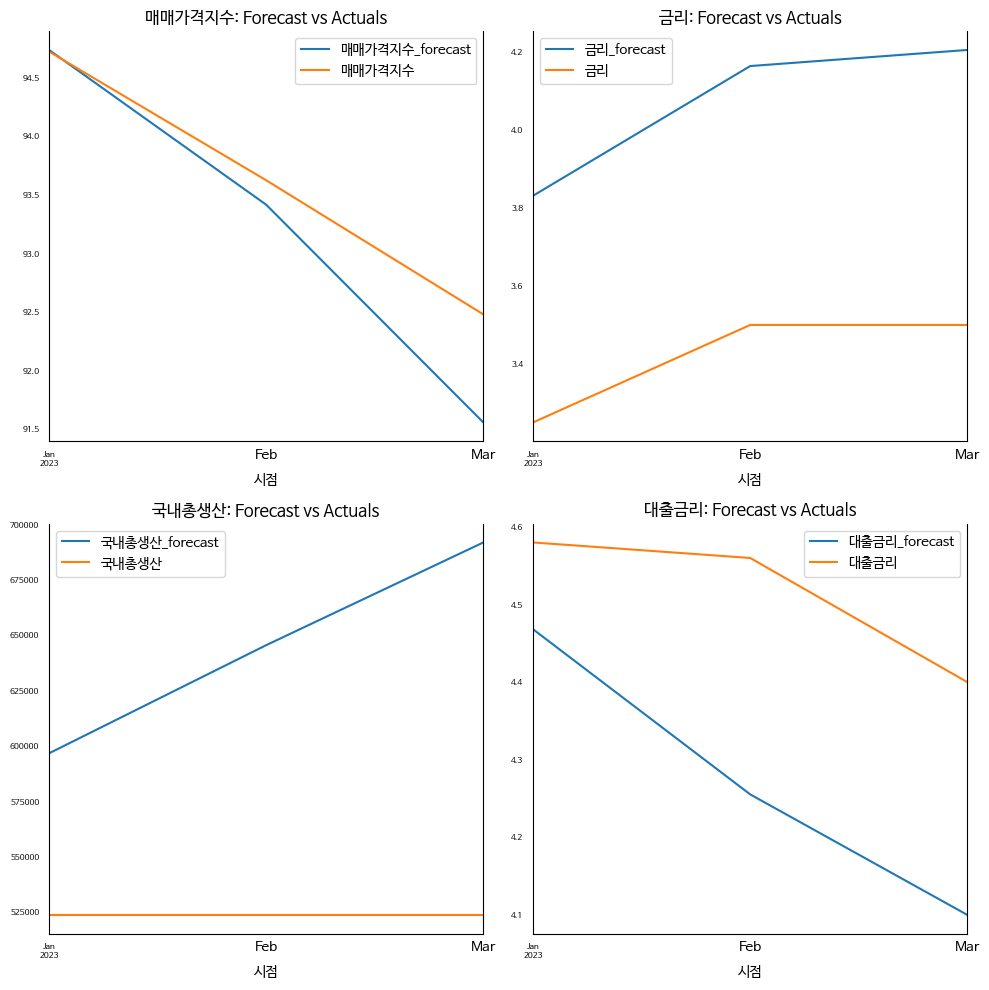

In [ ]:
fig, axes = plt.subplots(nrows=int(len(df.columns)/2), ncols=2, dpi=100, figsize=(10,10))
for i, (col,ax) in enumerate(zip(df.columns, axes.flatten())):
    df_results[col+'_forecast'].plot(legend=True, ax=ax).autoscale(axis='x',tight=True)
    df_test[col][-nobs:].plot(legend=True, ax=ax);
    ax.set_title(col + ": Forecast vs Actuals")
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')
    ax.spines["top"].set_alpha(0)
    ax.tick_params(labelsize=6)

plt.tight_layout();

In [ ]:
from statsmodels.tsa.stattools import acf
def forecast_accuracy(forecast, actual):
    mape = np.mean(np.abs(forecast - actual)/np.abs(actual))  # MAPE
    me = np.mean(forecast - actual)             # ME
    mae = np.mean(np.abs(forecast - actual))    # MAE
    mpe = np.mean((forecast - actual)/actual)   # MPE
    rmse = np.mean((forecast - actual)**2)**.5  # RMSE
    corr = np.corrcoef(forecast, actual)[0,1]   # corr
    mins = np.amin(np.hstack([forecast[:,None],
                              actual[:,None]]), axis=1)
    maxs = np.amax(np.hstack([forecast[:,None],
                              actual[:,None]]), axis=1)
    minmax = 1 - np.mean(mins/maxs)             # minmax
    return({'mape':mape, 'me':me, 'mae': mae,
            'mpe': mpe, 'rmse':rmse, 'corr':corr, 'minmax':minmax})

print('Forecast Accuracy of: 매매가격지수')
accuracy_prod = forecast_accuracy(df_results['매매가격지수_forecast'].values, df_test['매매가격지수'])
for k, v in accuracy_prod.items():
    print(adjust(k), ': ', round(v,4))

Forecast Accuracy of: 매매가격지수
mape   :  0.0041
me     :  -0.3722
mae    :  0.3815
mpe    :  -0.004
rmse   :  0.5458
corr   :  0.9964
minmax :  0.0041


In [ ]:
from sklearn.metrics import mean_squared_error

# 실제값과 예측값을 정의합니다.
actual_values = [93.08986685, 92.79213147, 92.48188788]
forecast_values = [94.738252, 93.417525, 91.559934]

# 각 쌍에 대한 RMSE를 계산합니다.
rmse_values = [np.sqrt(mean_squared_error([actual], [forecast])) for actual, forecast in zip(actual_values, forecast_values)]

# 결과 출력
for actual, forecast, rmse in zip(actual_values, forecast_values, rmse_values):
    print(f'Actual: {actual}, Forecast: {forecast}, RMSE: {rmse:.4f}')

Actual: 93.08986685, Forecast: 94.738252, RMSE: 1.6484
Actual: 92.79213147, Forecast: 93.417525, RMSE: 0.6254
Actual: 92.48188788, Forecast: 91.559934, RMSE: 0.9220


## 심리지수 있는 ver

In [ ]:
# 심리지수 포함.ver
df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/한이음/시계열_base_최종.xlsx')
df = df.drop(df.columns[0], axis=1)
df.head()

,시점,심리지수,매매가격지수,국내총생산,금리,대출금리,아파트거래량
0,2019-01-01,122,75.859101,"455,551.1",1.75,3.12,91868
1,2019-02-01,114,75.772352,"455,551.1",1.75,3.08,78825
2,2019-03-01,171,75.626463,"455,551.1",1.75,3.04,90720
3,2019-04-01,174,75.443869,"480,832.1",1.75,2.98,89977
4,2019-05-01,183,75.339340,"480,832.1",1.75,2.93,82498


In [ ]:
df['매매가격지수'] = pd.to_numeric(df['매매가격지수'], errors='coerce')
df['국내총생산'] = df['국내총생산'].str.replace(',', '').astype(float)
df['대출금리'] = pd.to_numeric(df['대출금리'], errors='coerce')
df['아파트거래량'] = pd.to_numeric(df['아파트거래량'], errors='coerce')
df.dtypes

시점        datetime64[ns]
심리지수               int64
매매가격지수           float64
국내총생산            float64
금리               float64
대출금리             float64
아파트거래량             int64
dtype: object

In [ ]:
df.set_index('시점', inplace=True)
df.head()

,심리지수,매매가격지수,국내총생산,금리,대출금리,아파트거래량
시점,,,,,,
2019-01-01,122,75.859101,455551.1,1.75,3.12,91868
2019-02-01,114,75.772352,455551.1,1.75,3.08,78825
2019-03-01,171,75.626463,455551.1,1.75,3.04,90720
2019-04-01,174,75.443869,480832.1,1.75,2.98,89977
2019-05-01,183,75.339340,480832.1,1.75,2.93,82498


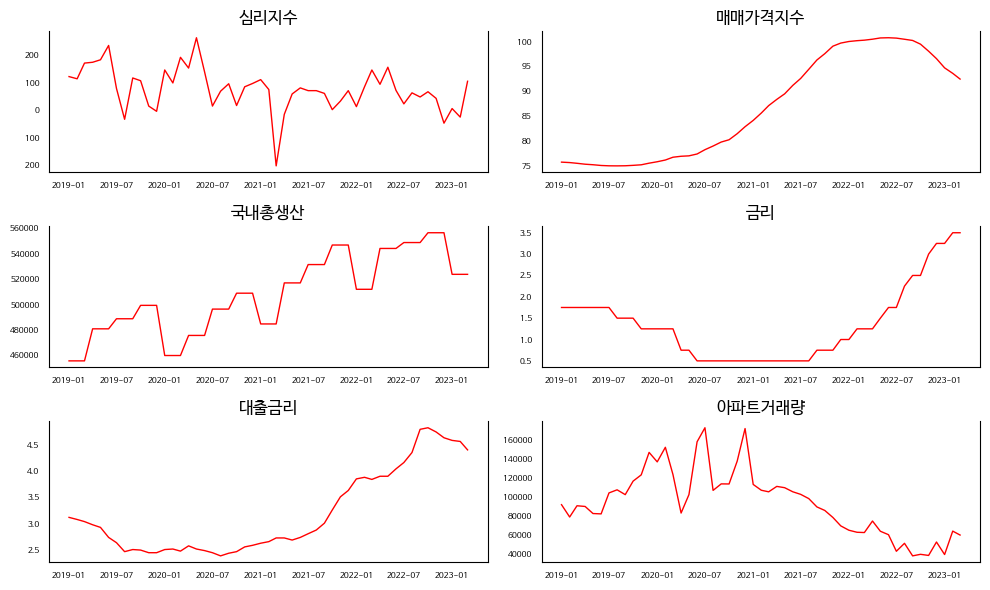

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=2, dpi=100, figsize=(10,6))
for i, ax in enumerate(axes.flatten()):
    data = df[df.columns[i]]
    ax.plot(data, color='red', linewidth=1)
    # Decorations
    ax.set_title(df.columns[i])
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')
    ax.spines["top"].set_alpha(0)
    ax.tick_params(labelsize=6)

plt.tight_layout();

In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests
maxlag=12
test = 'ssr_chi2test'
def grangers_causation_matrix(data, variables, test='ssr_chi2test', verbose=False):
    df = pd.DataFrame(np.zeros((len(variables), len(variables))), columns=variables, index=variables)
    for c in df.columns:
        for r in df.index:
            test_result = grangercausalitytests(data[[r, c]], maxlag=maxlag, verbose=False)
            p_values = [round(test_result[i+1][0][test][1],4) for i in range(maxlag)]
            if verbose: print(f'Y = {r}, X = {c}, P Values = {p_values}')
            min_p_value = np.min(p_values)
            df.loc[r, c] = min_p_value
    df.columns = [var + '_x' for var in variables]
    df.index = [var + '_y' for var in variables]
    return df

grangers_causation_matrix(df, variables = df.columns)

# p_value 0.05보다 값이 작은 경우
# 1) 국내총생산이 심리지수를 선행하며 영향을 끼침
# 1-1) 국내총생산이 매매가격지수를 선행하며 영향을 끼침
# 2) 아파트 거래량이 금리를 선행하며 영향을 끼침
# 3) 심리지수가 매매가격지수를 선행하며 영향을 끼침
# 3-1) 심리지수가 금리를 선행하며 영향을 끼침
# 3-2) 심리지수가 대출금리를 선행하며 영향을 끼침
# 3-3) 심리지수가 아파트거래량을 선행하며 영향을 끼침

,심리지수_x,매매가격지수_x,국내총생산_x,금리_x,대출금리_x,아파트거래량_x
심리지수_y,1.0000,0.0,0.0255,0.0,0.0,0.0000
매매가격지수_y,0.0009,1.0,0.0006,0.0,0.0,0.0000
국내총생산_y,0.0000,0.0,1.0000,0.0,0.0,0.0000
금리_y,0.0009,0.0,0.0000,1.0,0.0,0.0002
대출금리_y,0.0280,0.0,0.0000,0.0,1.0,0.0759
아파트거래량_y,0.0060,0.0,0.0000,0.0,0.0,1.0000


In [ ]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

def cointegration_test(df, alpha=0.05):
    out = coint_johansen(df,-1,5)
    d = {'0.90':0, '0.95':1, '0.99':2}
    traces = out.lr1
    cvts = out.cvt[:, d[str(1-alpha)]]
    def adjust(val, length= 6): return str(val).ljust(length)

    # Summary
    print('Name   ::  Test Stat > C(95%)    =>   Signif  \n', '--'*20)
    for col, trace, cvt in zip(df.columns, traces, cvts):
        print(adjust(col), ':: ', adjust(round(trace,2), 9), ">", adjust(cvt, 8), ' =>  ' , trace > cvt)

cointegration_test(df)
# 아파트거래량을 제외한 변수들 간에 유의미한 공적분 관계가 있음 -> 변수들 간 장기적인 경향 또는 상관관계가 존재함을 의미

Name   ::  Test Stat > C(95%)    =>   Signif  
 ----------------------------------------
심리지수   ::  337.51    > 83.9383   =>   True
매매가격지수 ::  215.48    > 60.0627   =>   True
국내총생산  ::  137.21    > 40.1749   =>   True
금리     ::  80.35     > 24.2761   =>   True
대출금리   ::  24.1      > 12.3212   =>   True
아파트거래량 ::  3.31      > 4.1296    =>   False


In [ ]:
nobs = 3
df_train, df_test = df[0:-nobs], df[-nobs:]

print(df_train.shape)
print(df_test.shape)

(48, 6)
(3, 6)


In [ ]:
def adfuller_test(series, signif=0.05, name='', verbose=False):
    """Perform ADFuller to test for Stationarity of given series and print report"""
    r = adfuller(series, autolag='AIC')
    output = {'test_statistic':round(r[0], 4), 'pvalue':round(r[1], 4), 'n_lags':round(r[2], 4), 'n_obs':r[3]}
    p_value = output['pvalue']
    def adjust(val, length= 6): return str(val).ljust(length)

    # Print Summary
    print(f'    Augmented Dickey-Fuller Test on "{name}"', "\n   ", '-'*47)
    print(f' Null Hypothesis: Data has unit root. Non-Stationary.')
    print(f' Significance Level    = {signif}')
    print(f' Test Statistic        = {output["test_statistic"]}')
    print(f' No. Lags Chosen       = {output["n_lags"]}')

    for key,val in r[4].items():
        print(f' Critical value {adjust(key)} = {round(val, 3)}')

    if p_value <= signif:
        print(f" => P-Value = {p_value}. Rejecting Null Hypothesis.")
        print(f" => Series is Stationary.")
    else:
        print(f" => P-Value = {p_value}. Weak evidence to reject the Null Hypothesis.")
        print(f" => Series is Non-Stationary.")

In [ ]:
for name, column in df_train.iteritems():
    adfuller_test(column, name=column.name)
    print('\n')

    Augmented Dickey-Fuller Test on "심리지수" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -4.1918
 No. Lags Chosen       = 0
 Critical value 1%     = -3.578
 Critical value 5%     = -2.925
 Critical value 10%    = -2.601
 => P-Value = 0.0007. Rejecting Null Hypothesis.
 => Series is Stationary.


    Augmented Dickey-Fuller Test on "매매가격지수" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -2.5496
 No. Lags Chosen       = 1
 Critical value 1%     = -3.581
 Critical value 5%     = -2.927
 Critical value 10%    = -2.602
 => P-Value = 0.1039. Weak evidence to reject the Null Hypothesis.
 => Series is Non-Stationary.


    Augmented Dickey-Fuller Test on "국내총생산" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.

In [ ]:
# 1차 차분 -> 심리지수, 국내총생산, 아파트거래량이 정상 시계열로 됨
df_differenced = df_train.diff().dropna()

In [ ]:
for name, column in df_differenced.iteritems():
    adfuller_test(column, name=column.name)
    print('\n')

    Augmented Dickey-Fuller Test on "심리지수" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -7.2076
 No. Lags Chosen       = 1
 Critical value 1%     = -3.585
 Critical value 5%     = -2.928
 Critical value 10%    = -2.602
 => P-Value = 0.0. Rejecting Null Hypothesis.
 => Series is Stationary.


    Augmented Dickey-Fuller Test on "매매가격지수" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -0.223
 No. Lags Chosen       = 0
 Critical value 1%     = -3.581
 Critical value 5%     = -2.927
 Critical value 10%    = -2.602
 => P-Value = 0.9357. Weak evidence to reject the Null Hypothesis.
 => Series is Non-Stationary.


    Augmented Dickey-Fuller Test on "국내총생산" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Si

In [ ]:
# 2차 차분 -> 모든 변수 다 정상시계열이 됨 ..?
df_differenced = df_differenced.diff().dropna()

In [ ]:
for name, column in df_differenced.iteritems():
    adfuller_test(column, name=column.name)
    print('\n')

    Augmented Dickey-Fuller Test on "심리지수" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -5.4262
 No. Lags Chosen       = 6
 Critical value 1%     = -3.61
 Critical value 5%     = -2.939
 Critical value 10%    = -2.608
 => P-Value = 0.0. Rejecting Null Hypothesis.
 => Series is Stationary.


    Augmented Dickey-Fuller Test on "매매가격지수" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -6.8774
 No. Lags Chosen       = 0
 Critical value 1%     = -3.585
 Critical value 5%     = -2.928
 Critical value 10%    = -2.602
 => P-Value = 0.0. Rejecting Null Hypothesis.
 => Series is Stationary.


    Augmented Dickey-Fuller Test on "국내총생산" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.0

In [ ]:
model = VAR(df_differenced)
for i in [1,2,3,4,5,6,7,8,9]:
    result = model.fit(i)
    print('Lag Order =', i)
    print('AIC : ', result.aic)
    print('BIC : ', result.bic)
    print('FPE : ', result.fpe)
    print('HQIC: ', result.hqic, '\n')

Lag Order = 1
AIC :  39.368088626977574
BIC :  41.054306950763205
FPE :  1.2705129703012462e+17
HQIC:  39.996693887805954 

Lag Order = 2
AIC :  39.37810811439265
BIC :  42.54098973815684
FPE :  1.4092975209313344e+17
HQIC:  40.551057097994956 

Lag Order = 3
AIC :  39.06509232362447
BIC :  43.73432053732368
FPE :  1.3679366224561331e+17
HQIC:  40.78695938523287 

Lag Order = 4
AIC :  37.73545248649665
BIC :  43.941415408937246
FPE :  7.243536165029314e+16
HQIC:  40.010183347249 

Lag Order = 5
AIC :  32.79490616073872
BIC :  40.568672121885086
FPE :  2793918777974484.5
HQIC:  35.625683118739836 

Lag Order = 6


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


LinAlgError: ignored

In [ ]:
x = model.select_order(maxlags=5)
x.summary()

,AIC,BIC,FPE,HQIC
0,40.31,40.56*,3.211e+17,40.40
1,39.78,41.53,1.924e+17,40.42
2,39.70,42.96,1.990e+17,40.88
3,39.09,43.86,1.507e+17,40.83
4,37.38,43.65,5.601e+16,39.66
5,32.79*,40.57,2.794e+15*,35.63*


In [ ]:
model_fitted = model.fit(5)
model_fitted.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 12, Nov, 2023
Time:                     15:47:54
--------------------------------------------------------------------
No. of Equations:         6.00000    BIC:                    40.5687
Nobs:                     41.0000    HQIC:                   35.6257
Log likelihood:          -835.354    FPE:                2.79392e+15
AIC:                      32.7949    Det(Omega_mle):     9.52625e+13
--------------------------------------------------------------------
Results for equation 심리지수
               coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------
const             4.829483         9.735300            0.496           0.620
L1.심리지수          -0.767295         0.153209           -5.008           0.000
L1.매매가격지수       -21.107205        92.110271           -0.229           0.819


In [ ]:
# 0~4 사이의 값을 가지며, 2에 가까울수록 상관성이 없는 것이고 0에 가까울수록 양의 상관성, 4에 가까울수록 음의 상관성이 존재

from statsmodels.stats.stattools import durbin_watson
def adjust(val, length=6):
    return str(val).ljust(length)
out = durbin_watson(model_fitted.resid)

for col, val in zip(df.columns, out):
    print(adjust(col), ':', round(val, 2))

심리지수   : 1.66
매매가격지수 : 2.22
국내총생산  : 1.37
금리     : 2.06
대출금리   : 1.45
아파트거래량 : 1.75


In [ ]:
lag_order = model_fitted.k_ar
print(lag_order)  #> 4

# Input data for forecasting
forecast_input = df_differenced.values[-lag_order:]
forecast_input

5


array([[ 8.90000000e+01, -1.53387768e-01, -4.65270000e+03,
         5.00000000e-01,  7.00000000e-02,  2.59360000e+04],
       [-5.50000000e+01, -1.28011727e-02,  0.00000000e+00,
        -2.50000000e-01,  2.50000000e-01, -2.16920000e+04],
       [ 3.40000000e+01, -4.99383207e-01,  7.73620000e+03,
        -2.50000000e-01, -4.10000000e-01,  1.49220000e+04],
       [-4.30000000e+01, -6.71258829e-01, -7.73620000e+03,
         5.00000000e-01, -1.10000000e-01, -2.82500000e+03],
       [-6.60000000e+01, -7.60992586e-02,  0.00000000e+00,
        -2.50000000e-01, -3.00000000e-02,  1.53820000e+04]])

In [ ]:
fc = model_fitted.forecast(y=forecast_input, steps=nobs)
df_forecast = pd.DataFrame(fc, index=df.index[-nobs:], columns=df.columns + '_2d')
df_forecast

,심리지수_2d,매매가격지수_2d,국내총생산_2d,금리_2d,대출금리_2d,아파트거래량_2d
시점,,,,,,
2023-01-01,31.069394,-0.860955,25438.813030,-0.142459,-0.279188,-41414.707283
2023-02-01,329.804227,0.577936,23310.486435,0.276768,0.042725,36261.947105
2023-03-01,-306.936382,0.178916,4507.543726,-0.241196,0.238167,12910.207238


In [ ]:
# 2번 차분했으므로 원래 값을 얻기 위한 변환

def invert_transformation(df_train, df_forecast, second_diff=False):
    """Revert back the differencing to get the forecast to original scale."""
    df_fc = df_forecast.copy()
    columns = df_train.columns
    for col in columns:
        # Roll back 2nd Diff
        if second_diff:
            df_fc[str(col)+'_1d'] = (df_train[col].iloc[-1]-df_train[col].iloc[-2]) + df_fc[str(col)+'_2d'].cumsum()
        # Roll back 1st Diff
        df_fc[str(col)+'_forecast'] = df_train[col].iloc[-1] + df_fc[str(col)+'_1d'].cumsum()
    return df_fc

In [ ]:
df_results = invert_transformation(df_train, df_forecast, second_diff=True)
df_results.loc[:, ['심리지수_forecast', '매매가격지수_forecast', '금리_forecast', '국내총생산_forecast', '대출금리_forecast',
                   '아파트거래량_forecast']]

,심리지수_forecast,매매가격지수_forecast,금리_forecast,국내총생산_forecast,대출금리_forecast,아파트거래량_forecast
시점,,,,,,
2023-01-01,-105.930606,94.221370,3.357541,582067.513030,4.240812,25169.292717
2023-02-01,164.943014,92.450801,3.741850,630816.812495,3.894350,34215.532539
2023-03-01,128.880253,90.859150,3.884963,684073.655687,3.786055,56171.979598


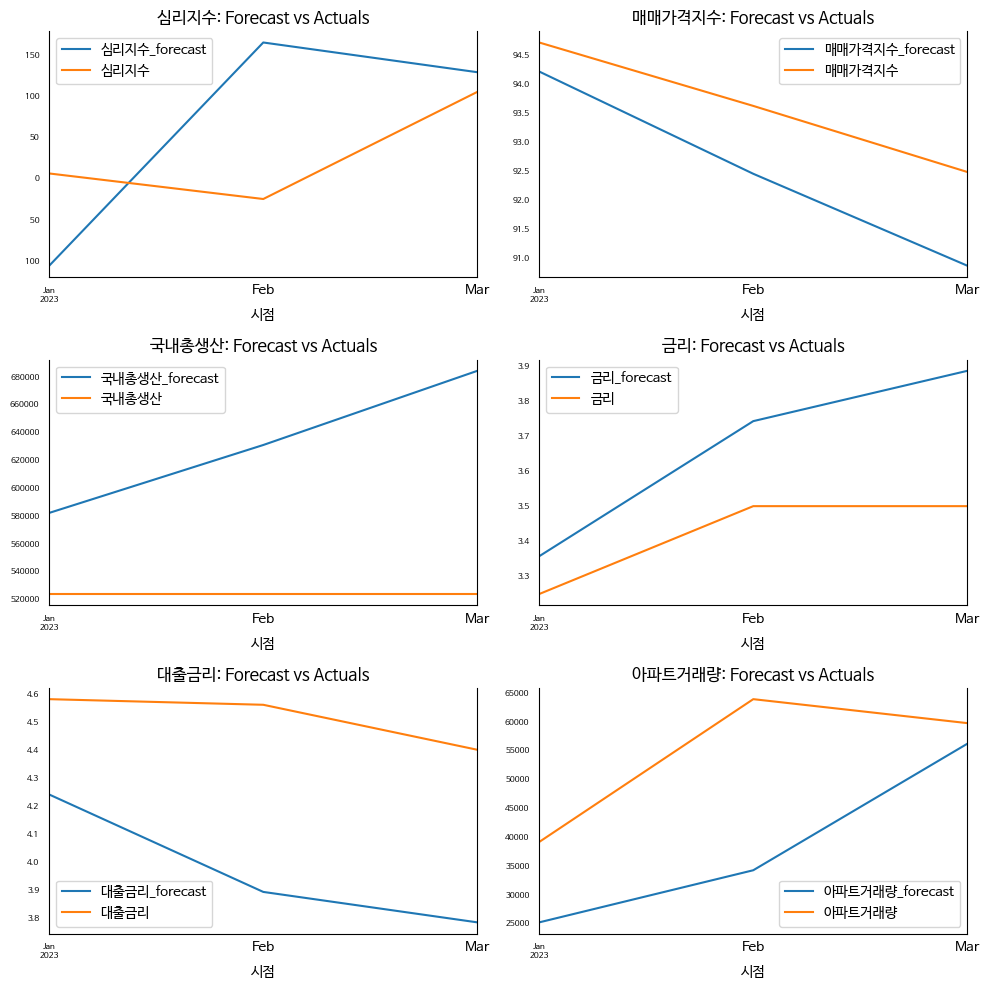

In [ ]:
fig, axes = plt.subplots(nrows=int(len(df.columns)/2), ncols=2, dpi=100, figsize=(10,10))
for i, (col,ax) in enumerate(zip(df.columns, axes.flatten())):
    df_results[col+'_forecast'].plot(legend=True, ax=ax).autoscale(axis='x',tight=True)
    df_test[col][-nobs:].plot(legend=True, ax=ax);
    ax.set_title(col + ": Forecast vs Actuals")
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')
    ax.spines["top"].set_alpha(0)
    ax.tick_params(labelsize=6)

plt.tight_layout();

In [ ]:
from statsmodels.tsa.stattools import acf
def forecast_accuracy(forecast, actual):
    mape = np.mean(np.abs(forecast - actual)/np.abs(actual))  # MAPE
    me = np.mean(forecast - actual)             # ME
    mae = np.mean(np.abs(forecast - actual))    # MAE
    mpe = np.mean((forecast - actual)/actual)   # MPE
    rmse = np.mean((forecast - actual)**2)**.5  # RMSE
    corr = np.corrcoef(forecast, actual)[0,1]   # corr
    mins = np.amin(np.hstack([forecast[:,None],
                              actual[:,None]]), axis=1)
    maxs = np.amax(np.hstack([forecast[:,None],
                              actual[:,None]]), axis=1)
    minmax = 1 - np.mean(mins/maxs)             # minmax
    return({'mape':mape, 'me':me, 'mae': mae,
            'mpe': mpe, 'rmse':rmse, 'corr':corr, 'minmax':minmax})

print('Forecast Accuracy of: 매매가격지수')
accuracy_prod = forecast_accuracy(df_results['매매가격지수_forecast'].values, df_test['매매가격지수'])
for k, v in accuracy_prod.items():
    print(adjust(k), ': ', round(v,4))

Forecast Accuracy of: 매매가격지수
mape   :  0.0118
me     :  -1.1003
mae    :  1.1003
mpe    :  -0.0118
rmse   :  1.1927
corr   :  0.9991
minmax :  0.0118


In [ ]:
RMSE: 1.6484
Actual: 92.79213147, Forecast: 93.417525, RMSE: 0.6254
Actual: 92.48188788, Forecast: 91.559934, RMSE: 0.9220

In [ ]:
from sklearn.metrics import mean_squared_error

# 실제값과 예측값을 정의합니다.
actual_values = [93.08986685, 92.79213147, 92.48188788]
forecast_values = [94.221370, 92.450801, 90.859150]

# 각 쌍에 대한 RMSE를 계산합니다.
rmse_values = [np.sqrt(mean_squared_error([actual], [forecast])) for actual, forecast in zip(actual_values, forecast_values)]

# 결과 출력
for actual, forecast, rmse in zip(actual_values, forecast_values, rmse_values):
    print(f'Actual: {actual}, Forecast: {forecast}, RMSE: {rmse:.4f}')

Actual: 93.08986685, Forecast: 94.22137, RMSE: 1.1315
Actual: 92.79213147, Forecast: 92.450801, RMSE: 0.3413
Actual: 92.48188788, Forecast: 90.85915, RMSE: 1.6227


# 새 섹션

In [ ]:
# https://github.com/elvinwangyh/Medium/blob/main/Monetary_transmission_mechanism.ipynb?source=post_page-----d4dd87cfe435--------------------------------
# https://medium.com/@yuhui_w/monetary-transmission-mechanism-vector-autoregression-var-approach-d4dd87cfe435

In [ ]:
import datetime as dt

import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.tsa.api as tsa
from statsmodels.tsa.api import VAR, VARMAX

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

import pandas_datareader.data as web
import yfinance as yf

In [ ]:
df.head(3)

,심리지수,매매가격지수,국내총생산,금리,대출금리,아파트거래량
시점,,,,,,
2019-01-01,122,75.859101,455551.1,1.75,3.12,91868
2019-02-01,114,75.772352,455551.1,1.75,3.08,78825
2019-03-01,171,75.626463,455551.1,1.75,3.04,90720


In [ ]:
def coint_matrix(data):
    coint_matrix = pd.DataFrame(index=data.columns, columns=data.columns)
    for i in data.columns:
        for j in data.columns:
            if i != j:
                x = data[i]
                y = data[j]
                result = sm.tsa.stattools.coint(x, y)
                coint_matrix.loc[i,j] = result[1]
    # fill nan will 0
    coint_matrix = coint_matrix.fillna(0)
    return coint_matrix

<Axes: >

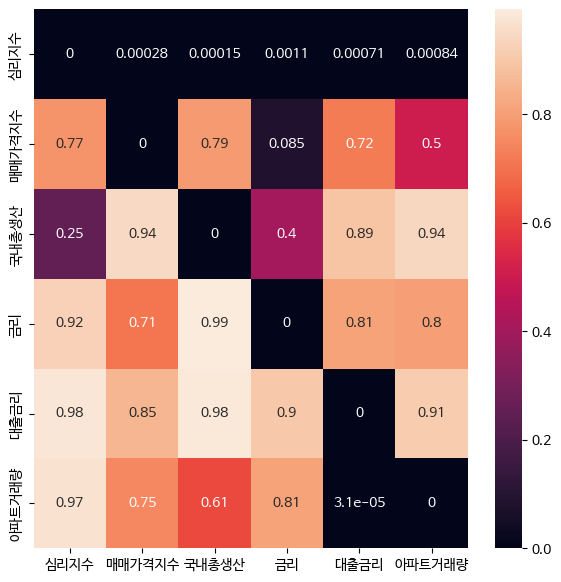

In [ ]:
coint = coint_matrix(df)

plt.subplots(figsize=(7, 7))
sns.heatmap(coint, annot=True)

In [ ]:
T2 = ['심리지수', '국내총생산', '아파트거래량']
T5 = ['매매가격지수', '금리', '대출금리']

df[T2] =df[T2].diff()
df[T5] = np.log(df[T5]).diff()

df.dropna(inplace=True)
df.head()

,심리지수,매매가격지수,국내총생산,금리,대출금리,아파트거래량
시점,,,,,,
2019-02-01,-8.0,-0.001144,0.0,0.0,-0.012903,-13043.0
2019-03-01,57.0,-0.001927,0.0,0.0,-0.013072,11895.0
2019-04-01,3.0,-0.002417,25281.0,0.0,-0.019934,-743.0
2019-05-01,9.0,-0.001386,0.0,0.0,-0.016921,-7479.0
2019-06-01,52.0,-0.001988,0.0,0.0,-0.067045,-379.0


<Axes: xlabel='시점'>

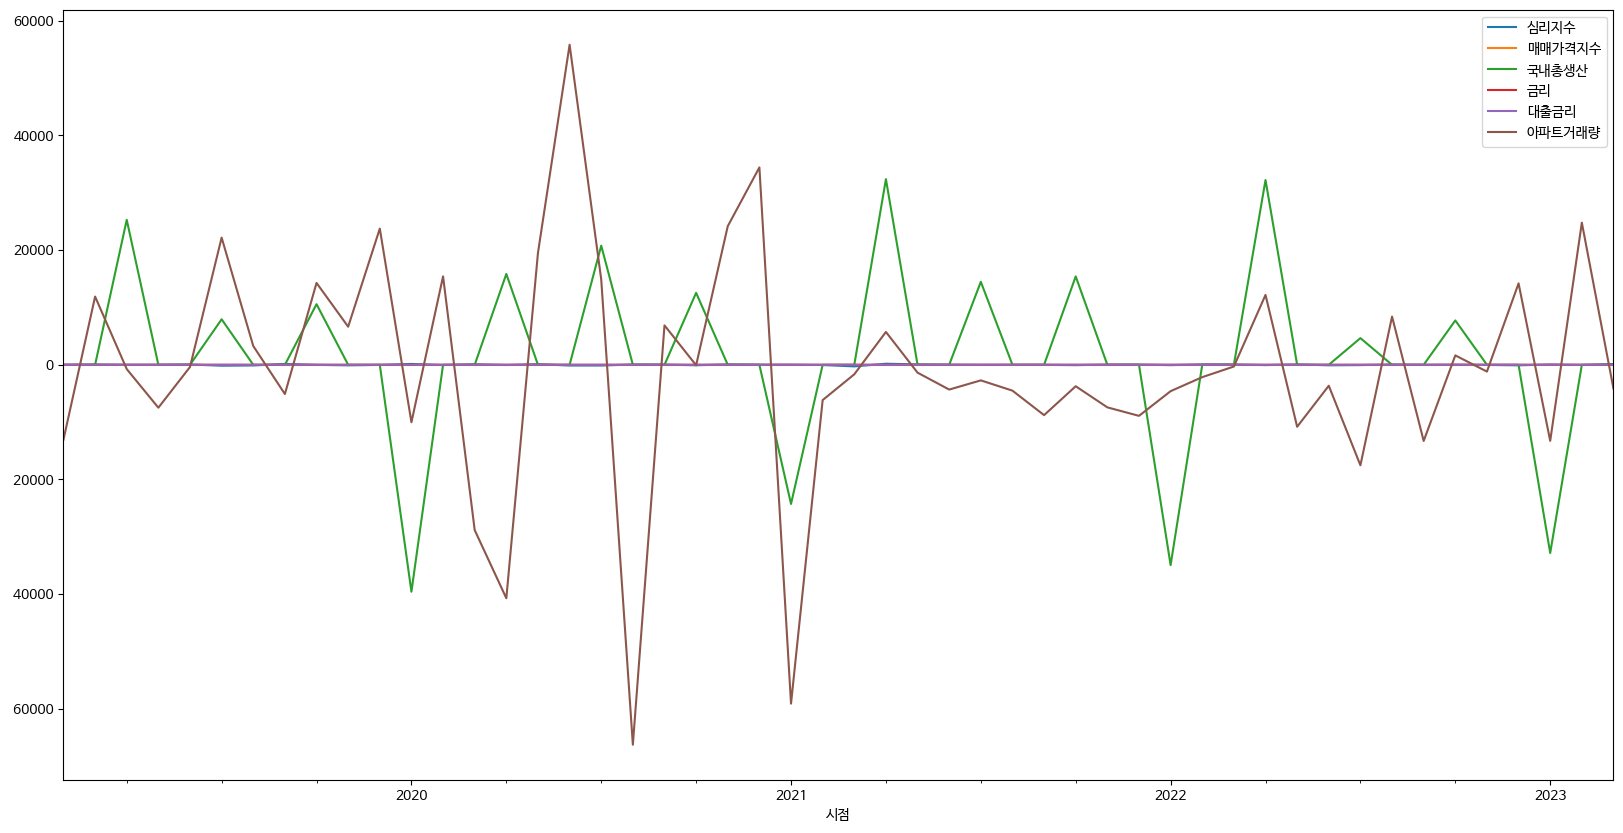

In [ ]:
df.plot(figsize=(20,10))

심리지수


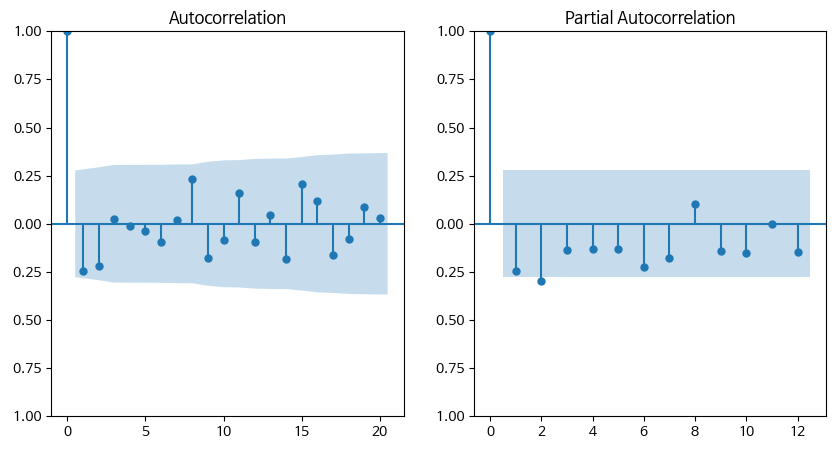

매매가격지수


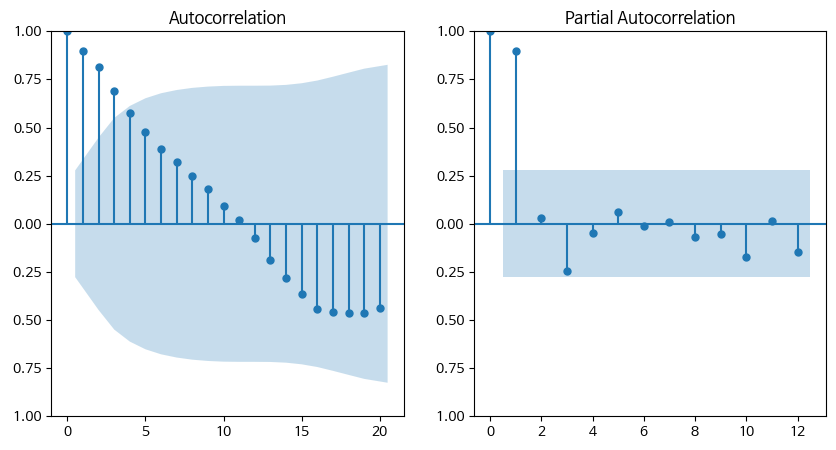

국내총생산


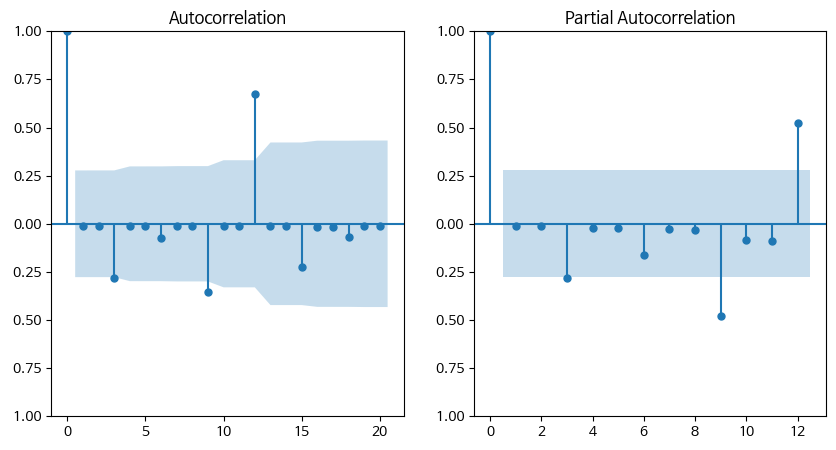

금리


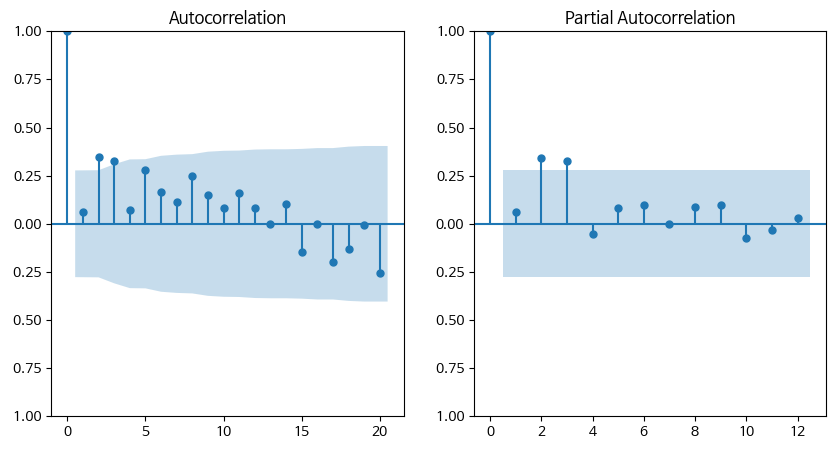

대출금리


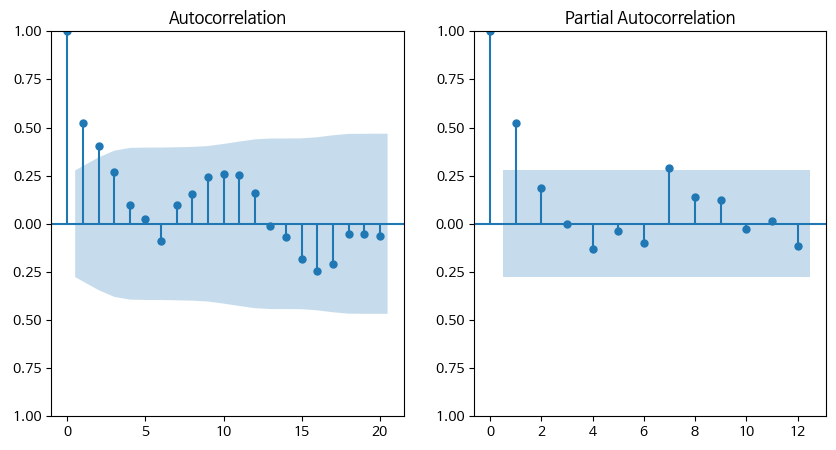

아파트거래량


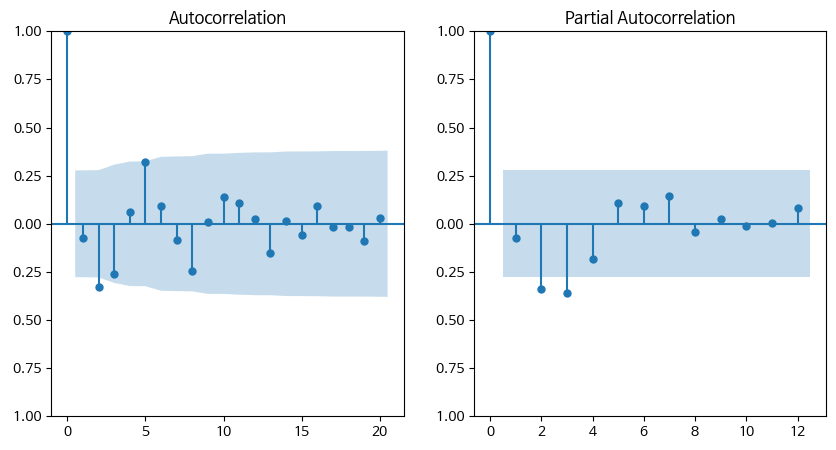

In [ ]:
for column in df.columns:
    print(column)
    fig, ax = plt.subplots(1,2,figsize=(10,5))
    sm.graphics.tsa.plot_acf(df[column], lags=20, ax=ax[0])
    sm.graphics.tsa.plot_pacf(df[column], lags=12, alpha=0.05, ax=ax[1])
    plt.show()

In [ ]:
output = []
for column in df.columns:
    pval = tsa.adfuller(df[column], regression='c', autolag='AIC')[1]
    output.append(pval)
output = pd.DataFrame(output).T
output.columns = df.columns
odd = output.columns[output.max() >= 0.05]
output[odd]

,매매가격지수,국내총생산,금리,대출금리
0,0.82337,0.68839,0.280503,0.08281


In [ ]:
maxlag = 5
VAR_model = VAR(df)
VAR_model.select_order(maxlag)
results = VAR_model.fit(maxlags=maxlag, ic='aic')
results.summary()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 12, Nov, 2023
Time:                     16:55:31
--------------------------------------------------------------------
No. of Equations:         6.00000    BIC:                    30.6974
Nobs:                     45.0000    HQIC:                   26.0136
Log likelihood:          -719.784    FPE:                8.06358e+10
AIC:                      23.2298    Det(Omega_mle):     3.47473e+09
--------------------------------------------------------------------
Results for equation 심리지수
               coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------
const           -17.205779        18.985654           -0.906           0.365
L1.심리지수          -0.582948         0.221834           -2.628           0.009
L1.매매가격지수     -1390.046494      6488.625079           -0.214           0.830


In [ ]:
lag_order = results.k_ar
lag_order

5

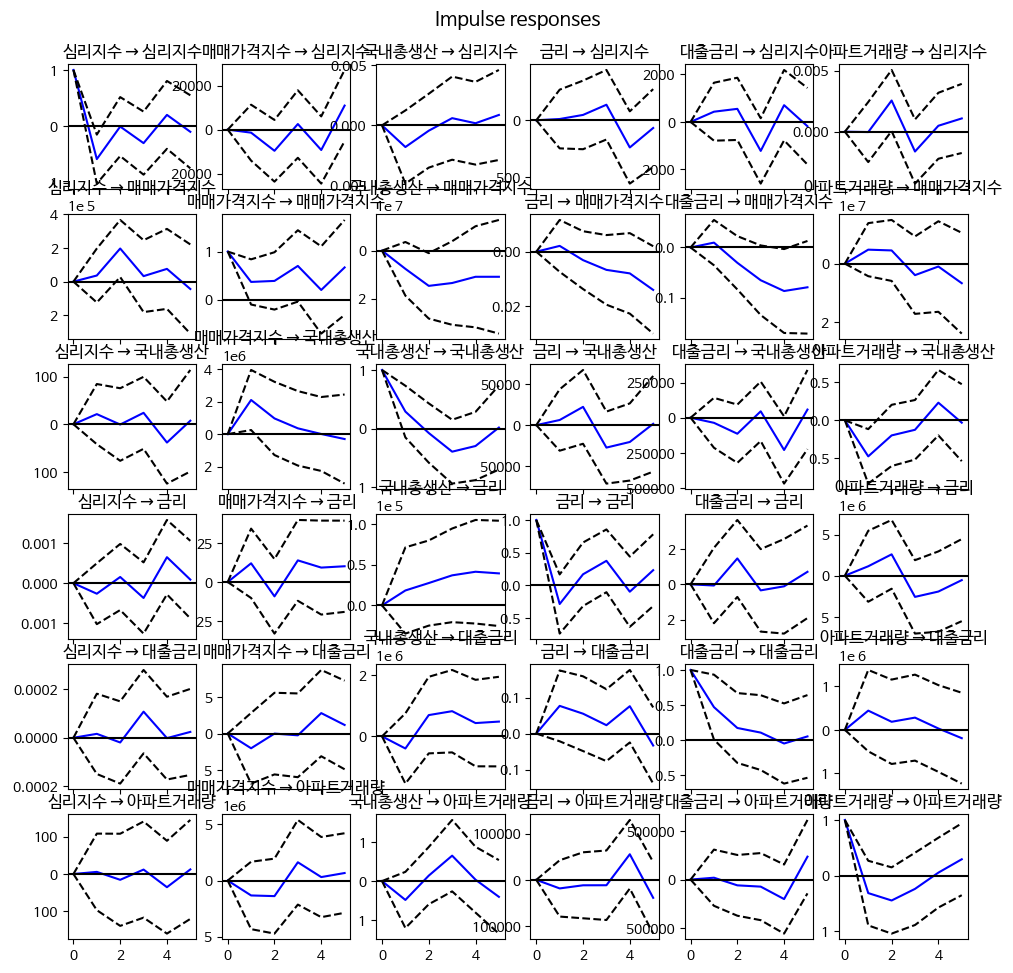

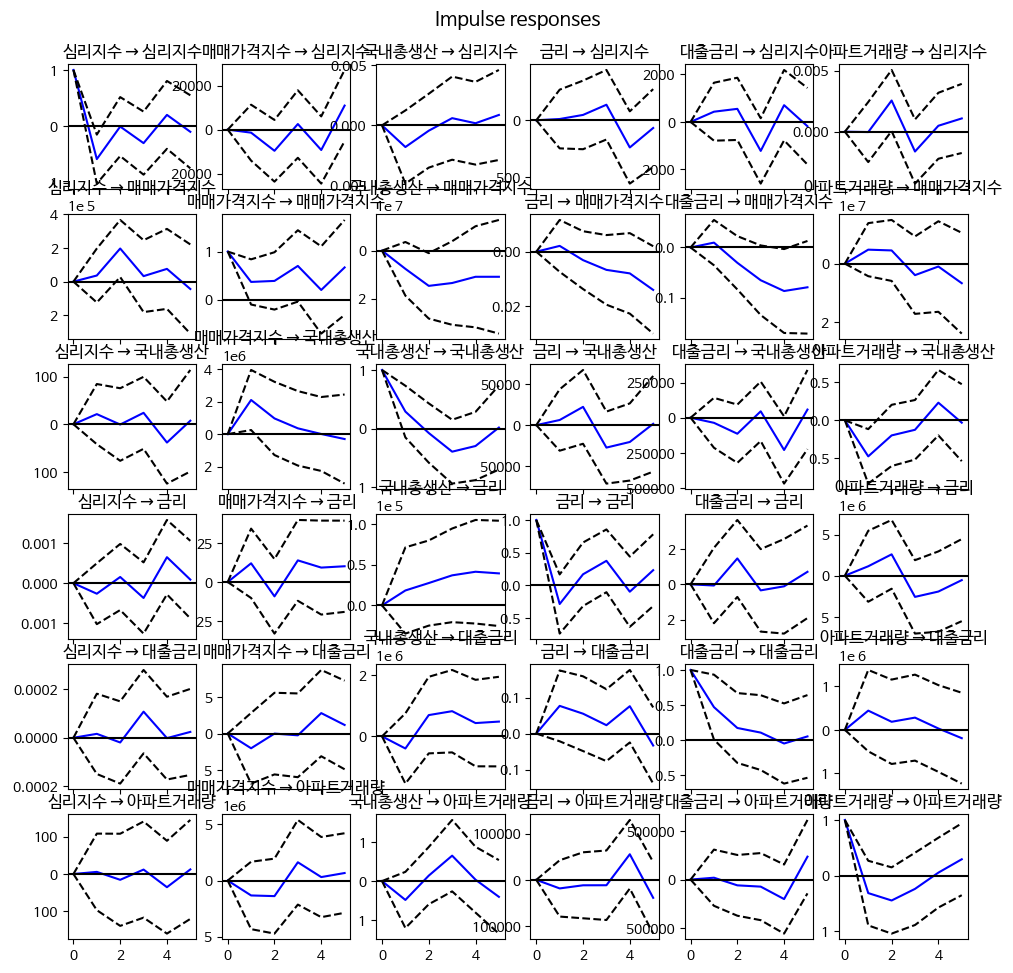

In [ ]:
irf = results.irf(maxlag)
irf.plot(orth=False, figsize=(10, 10))

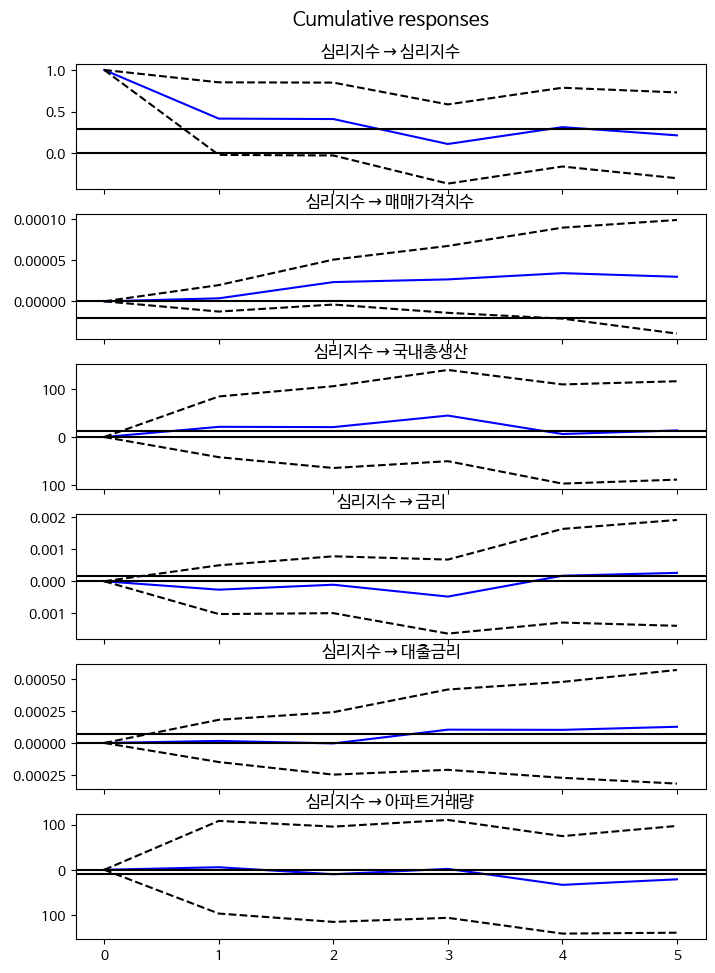

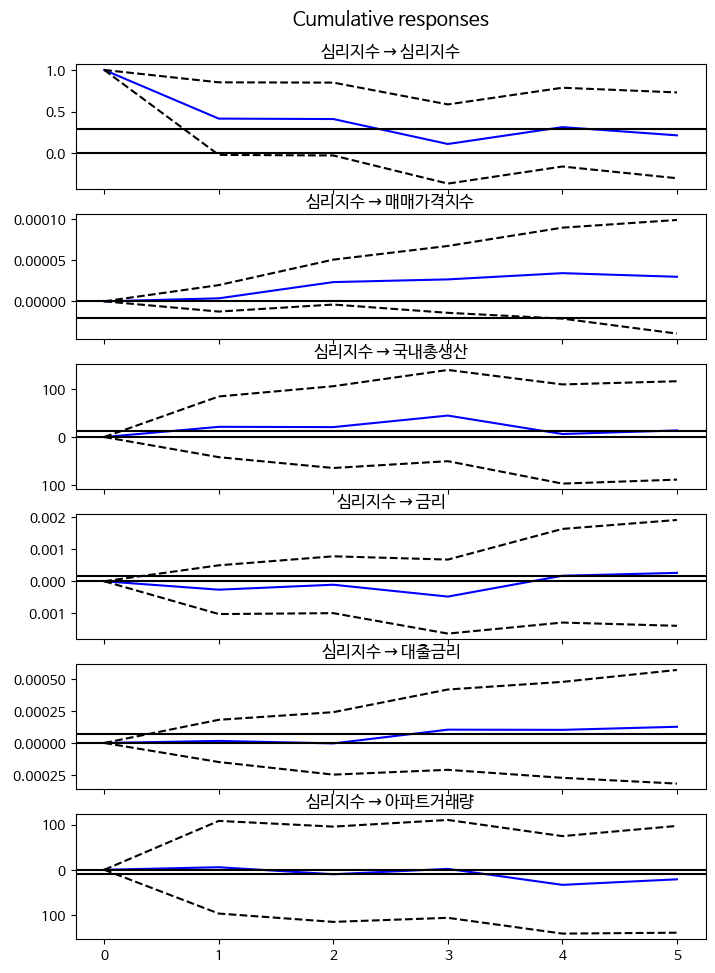

In [ ]:
irf.plot_cum_effects(impulse = '심리지수', orth=False, figsize=(7, 10))

# 새 섹션

In [ ]:
# https://github.com/susanli2016/Machine-Learning-with-Python/blob/master/Granger%20Causality%20Test.ipynb

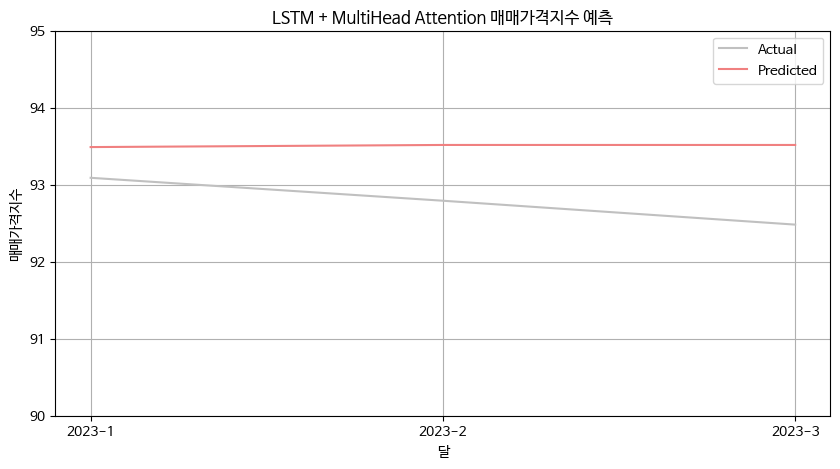

In [ ]:
import matplotlib.pyplot as plt

Y_test1 = [93.08986685, 92.79213147, 92.48188788]
Y_hat1 = [93.48888397, 93.51642609, 93.51628876]
plt.figure(figsize=(10, 5))
plt.plot(Y_test1, c='silver')
plt.plot(Y_hat1, c='lightcoral')
plt.xlabel('달', fontsize=10)
plt.ylabel('매매가격지수', fontsize=10)

plt.ylim(90, 95)

ticklabel = ['2023-1', '2023-2', '2023-3']
X = [0, 1, 2]
plt.xticks(X, ticklabel)

plt.title('LSTM + MultiHead Attention 매매가격지수 예측')
plt.legend(['Actual', 'Predicted'], loc='upper right')
plt.grid()
plt.show()

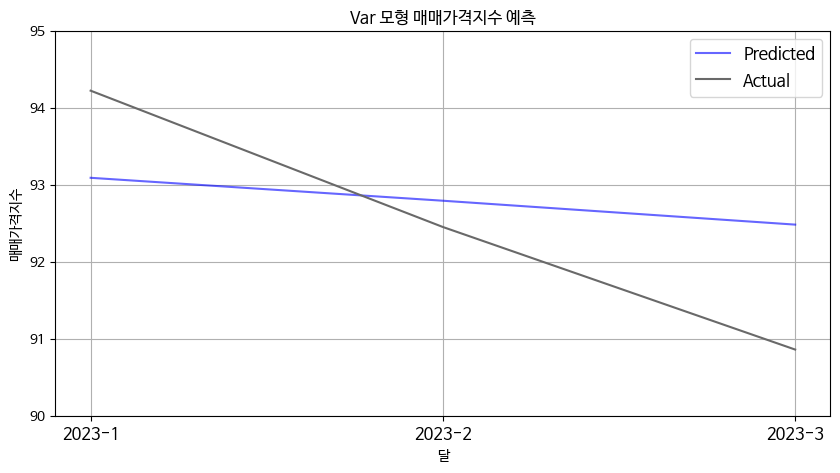

In [12]:
Y_test1 = [93.08986685, 92.79213147, 92.48188788]
Y_hat1 = [94.221370, 92.450801, 90.859150]
plt.figure(figsize=(10, 5))
plt.plot(Y_test1, c='blue', alpha=0.6)
plt.plot(Y_hat1, c='dimgray')
plt.xlabel('달', fontsize=10)
plt.ylabel('매매가격지수', fontsize=10)

plt.ylim(90, 95)

ticklabel = ['2023-1', '2023-2', '2023-3']
X = [0, 1, 2]
plt.xticks(X, ticklabel, fontsize=12)

plt.title('Var 모형 매매가격지수 예측')
plt.legend(['Predicted', 'Actual'], loc='upper right', fontsize=12)
plt.grid()
plt.show()

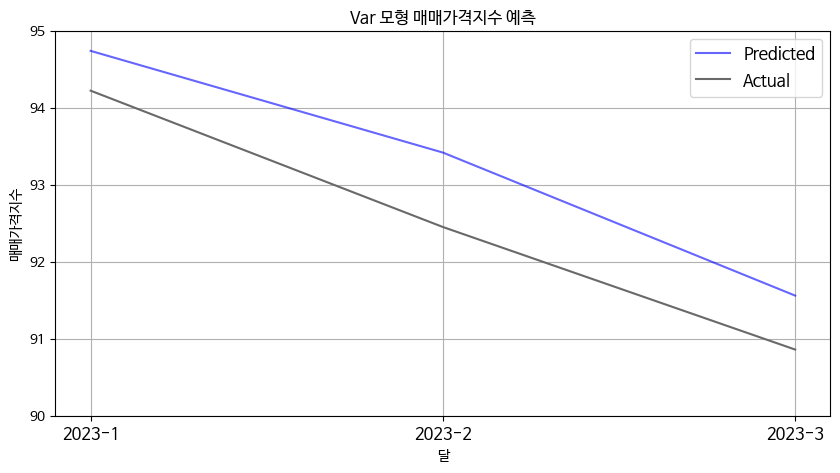

In [13]:
Y_test1 = [94.738252, 93.417525, 91.559934]
Y_hat1 = [94.221370, 92.450801, 90.859150]
plt.figure(figsize=(10, 5))
plt.plot(Y_test1, c='blue', alpha=0.6)
plt.plot(Y_hat1, c='dimgray')
plt.xlabel('달', fontsize=10)
plt.ylabel('매매가격지수', fontsize=10)

plt.ylim(90, 95)

ticklabel = ['2023-1', '2023-2', '2023-3']
X = [0, 1, 2]
plt.xticks(X, ticklabel, fontsize=12)

plt.title('Var 모형 매매가격지수 예측')
plt.legend(['Predicted', 'Actual'], loc='upper right', fontsize=12)
plt.grid()
plt.show()